<a href="https://colab.research.google.com/github/harshithat29/internship/blob/main/vtu/Week_9_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Prediction in Telecom Using Machine Learning**

**Problem Statement**

Problem Statement
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:

● Customer Age

● Gender

● Tenure

● Monthly Charges

● Total Charges

● Contract Type

● Payment Method

● Internet Service

● Tech Support

● Online Security

● Customer Support Calls

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.

**Objectives**

The objective of this task is to:

● Understand and explore the customer dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

**1.Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**2.Load the Dataset**

In [ ]:
df = pd.read_csv("telecom_churn_data.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


**3 .Check Dataset**

● Shape

● Columns

● Data types

● Summary statistics

In [ ]:
df.shape


(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7038,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7041,7043,7041.000000,7038,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6526,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3550,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4169,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.749581,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.085731,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**4.Handle Missing Values**

In [ ]:
# Check missing values
df.isnull().sum()

# Fill numerical columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify no missing values remain
df.isnull().sum()

/tmp/ipykernel_24467/2443895262.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**5.Remove Duplicate Records**

In [ ]:
# Check duplicate records
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

# Verify removal
df.duplicated().sum()

np.int64(0)

**6. Perform Univariate Analysis**

 ● Distribution of numerical features

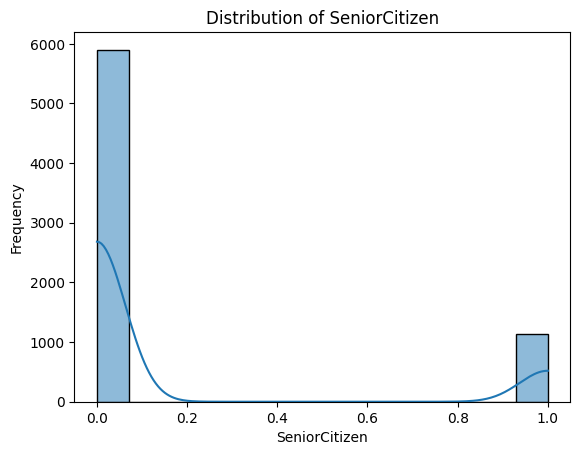

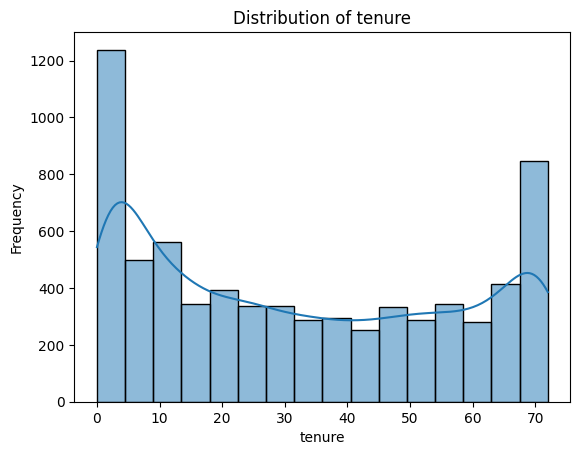

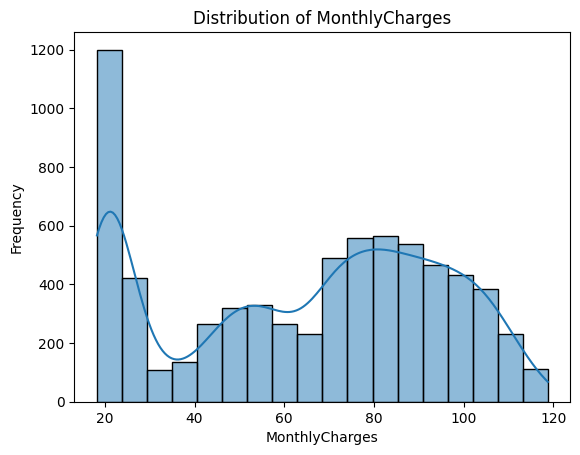

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Insights:

*Most values are skewed, not evenly distributed

*Tenure: More new customers → higher churn risk

*Monthly Charges: Different plans across customers

*Total Charges: Higher for long-term customers

*Support Calls: More calls → possible dissatisfaction

● Count plots for categorical features

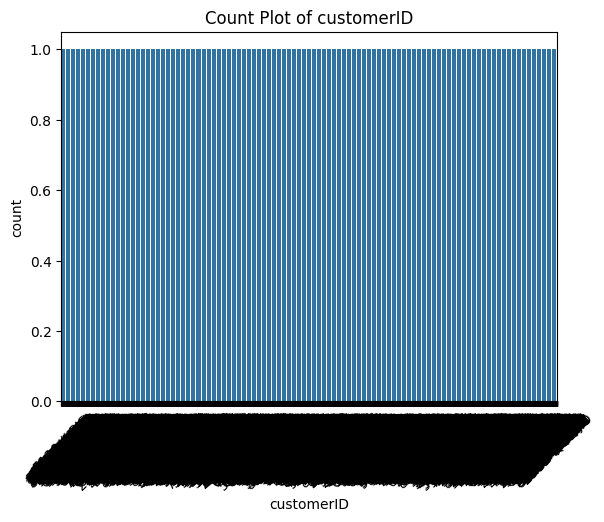

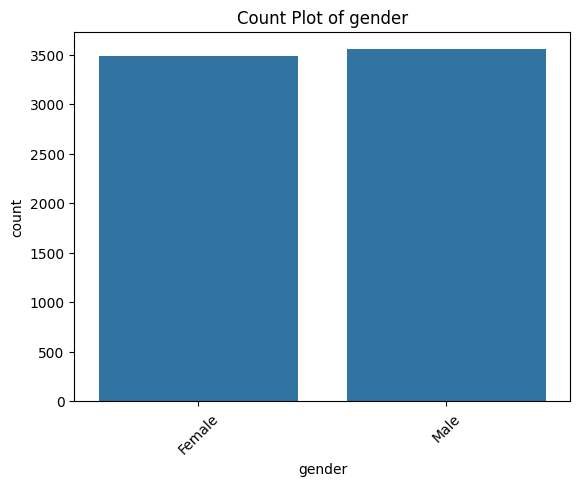

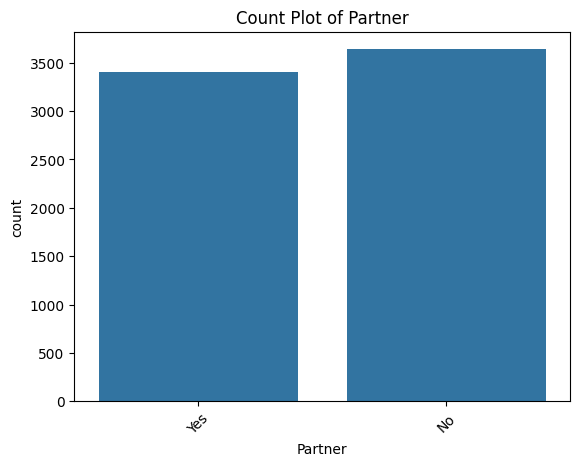

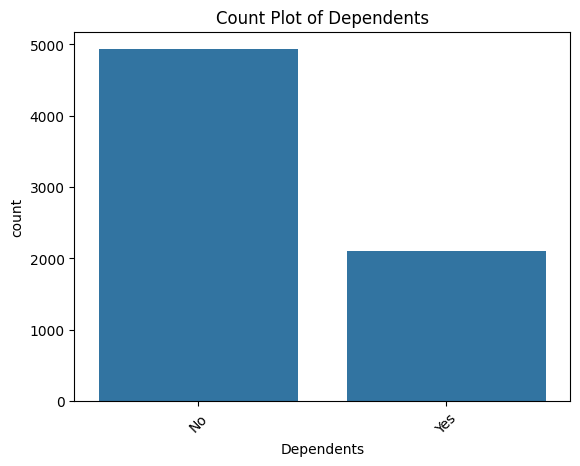

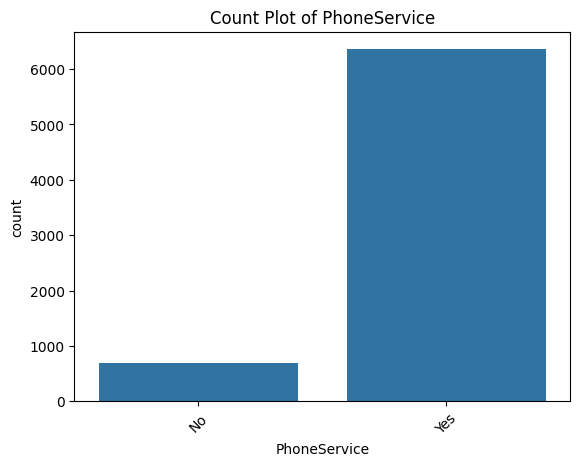

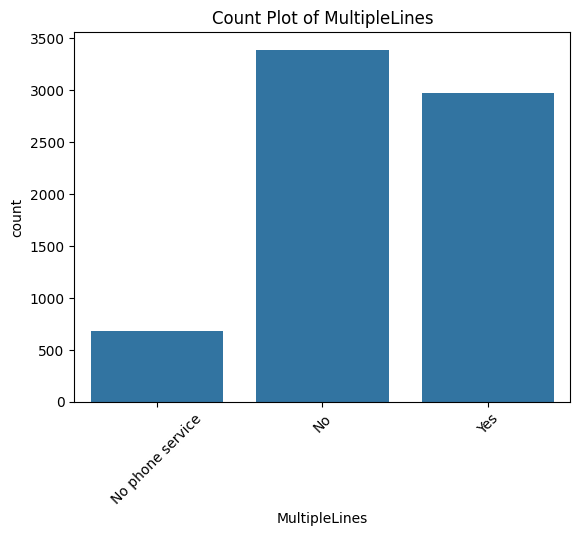

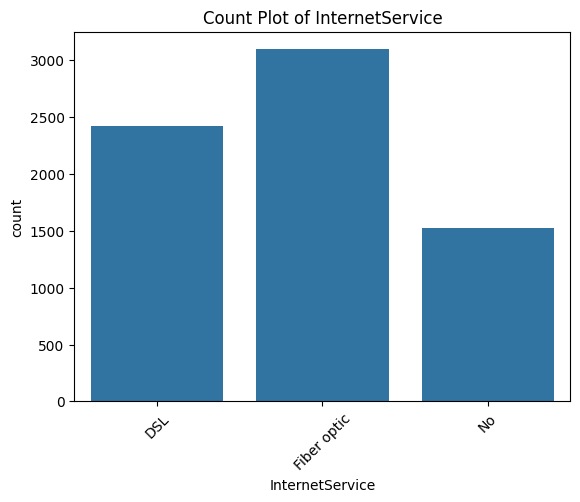

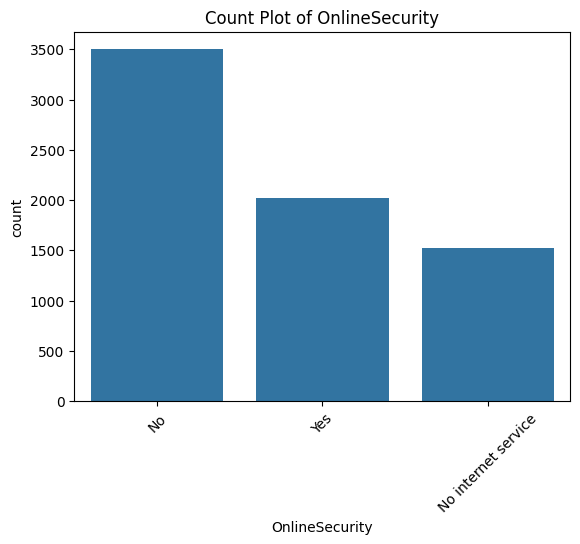

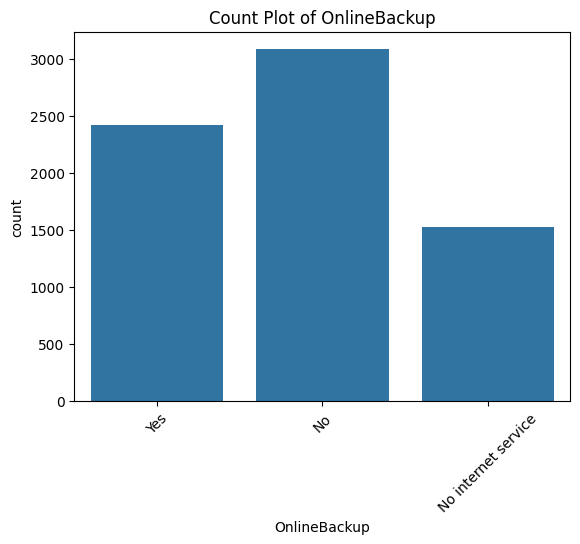

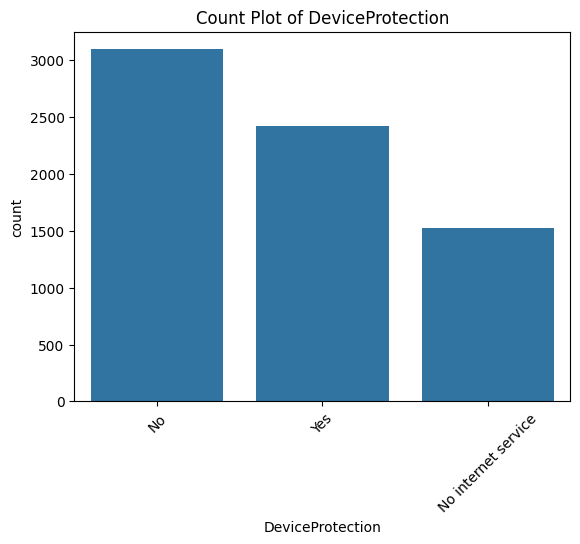

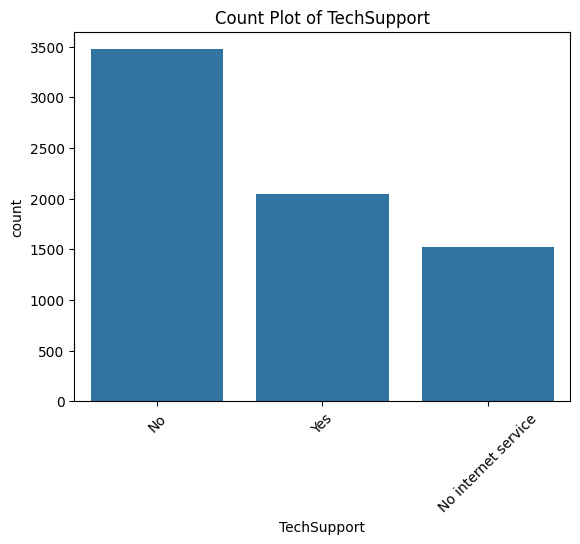

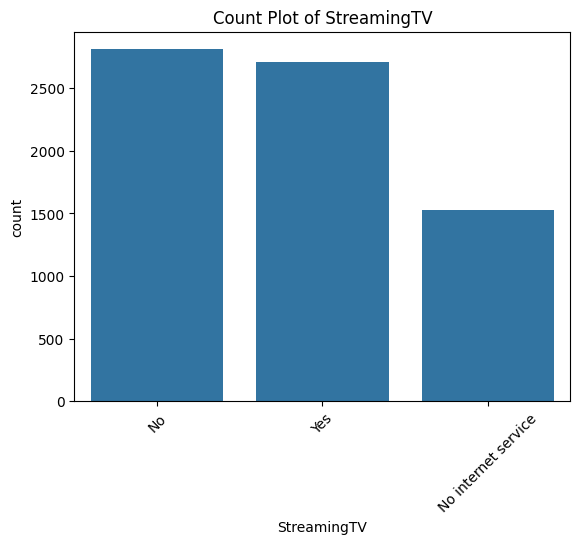

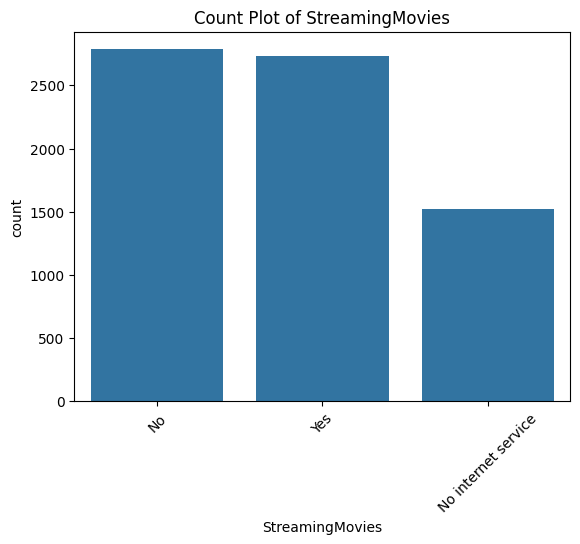

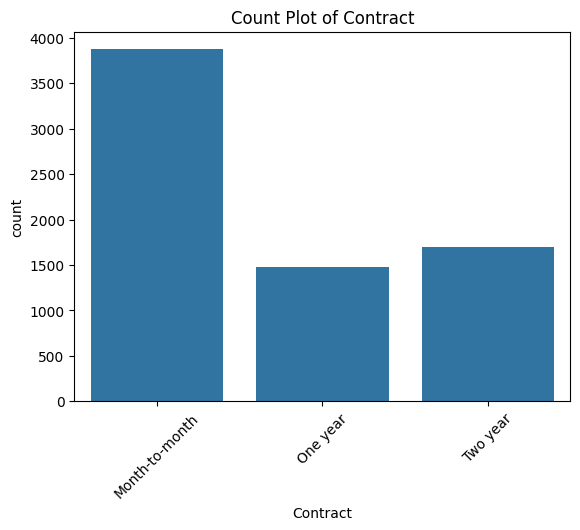

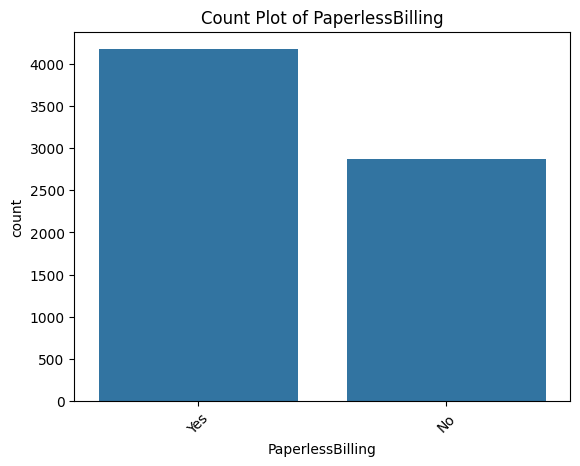

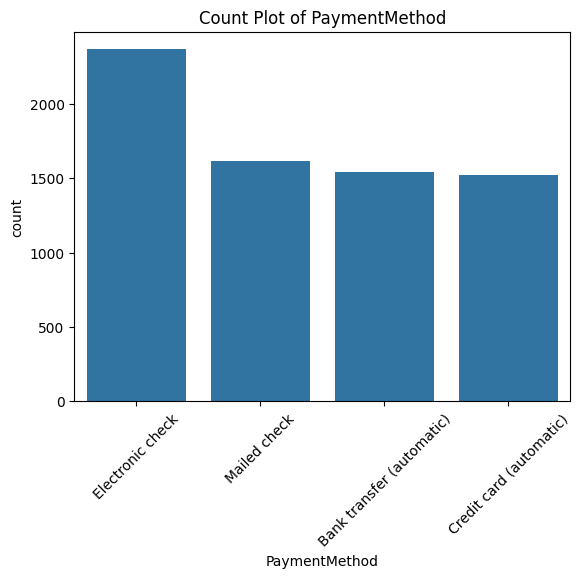

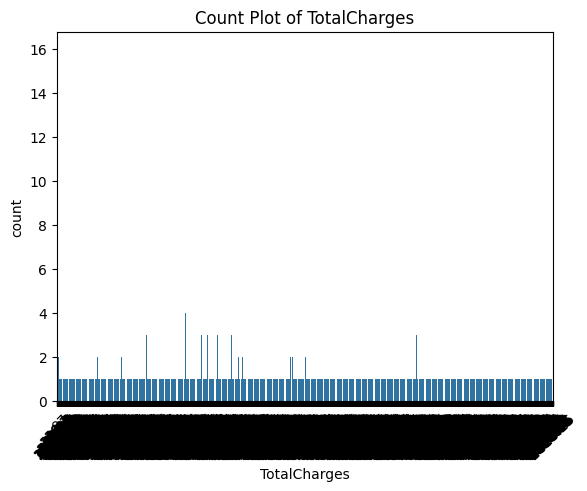

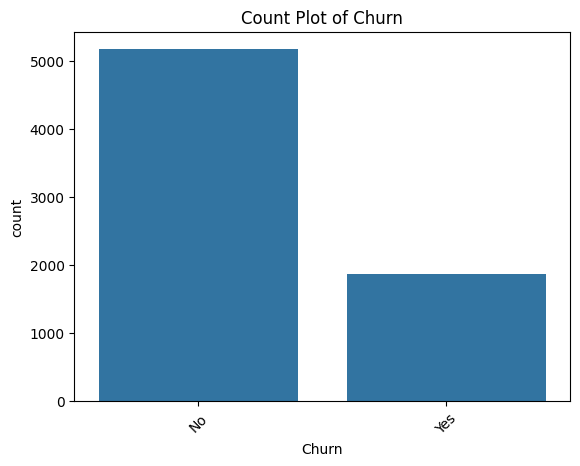

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

Insights:

*Gender: Distribution is almost equal → no major impact on churn

*Contract Type: Customers with month-to-month contracts churn more


*Payment Method: Certain methods (like electronic payments) show higher churn

*Internet Service: Some services have more churn-prone customers

*Tech Support & Online Security: Customers without these services are more likely to churn

**7.Perform Bivariate Analysis**

● Churn vs categorical features

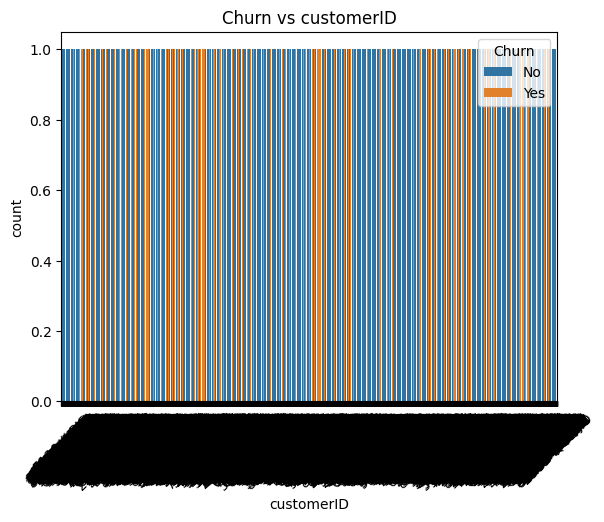

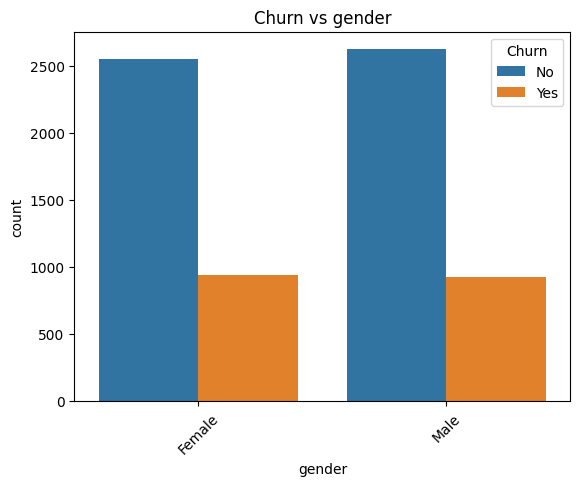

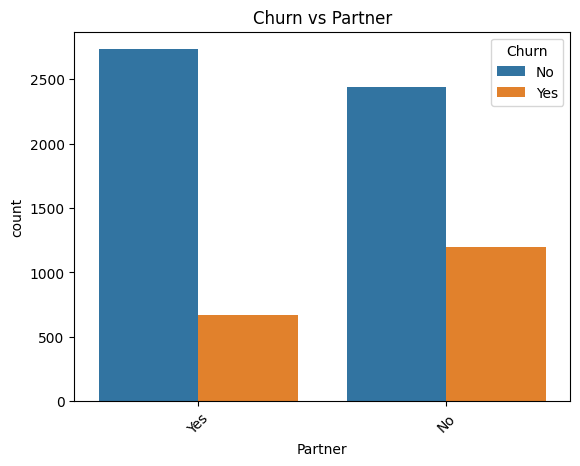

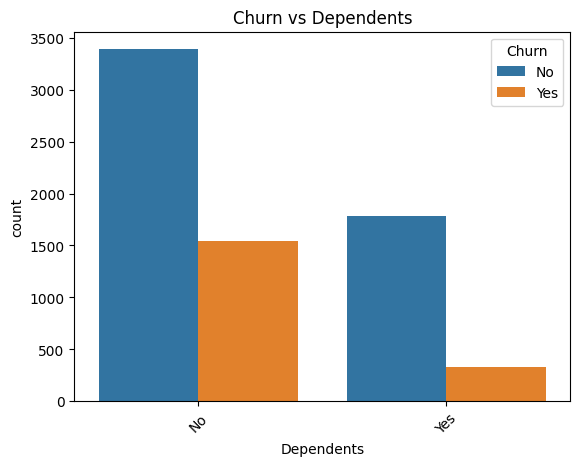

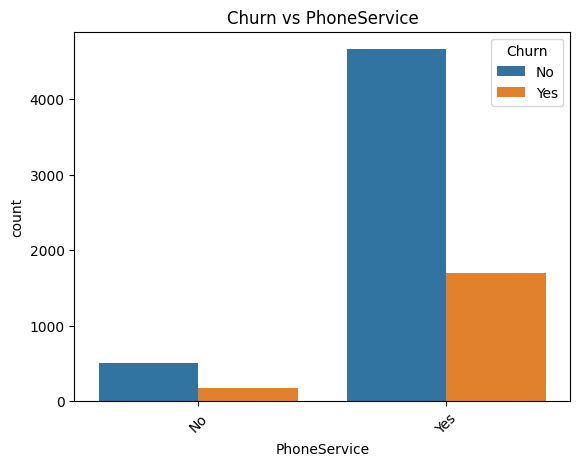

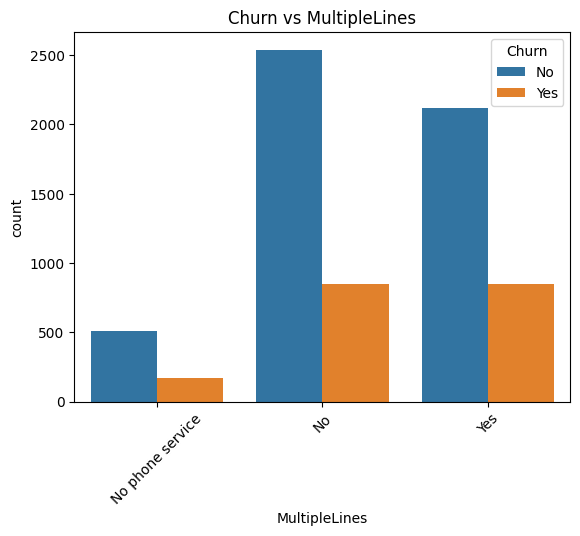

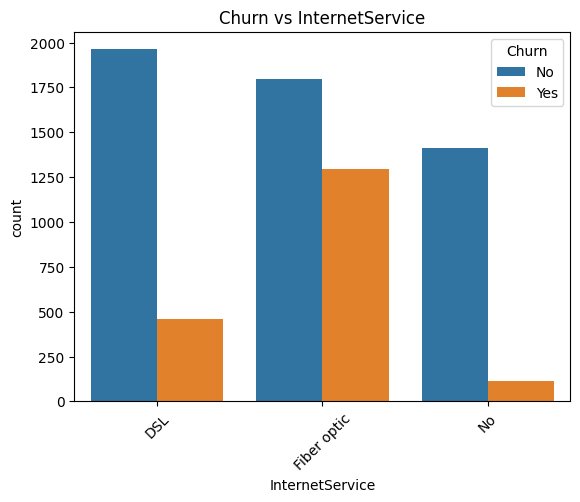

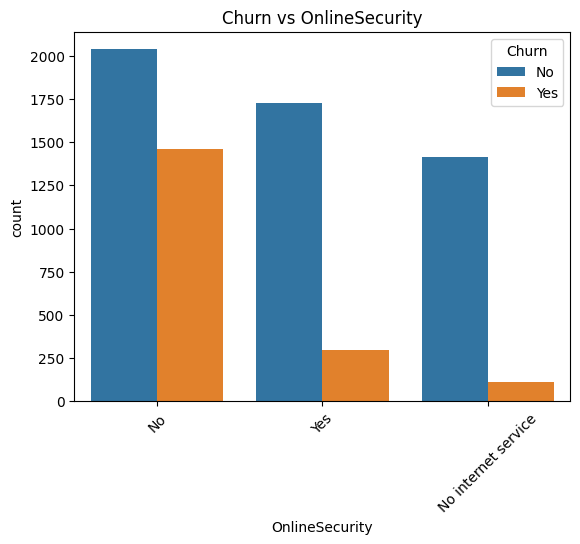

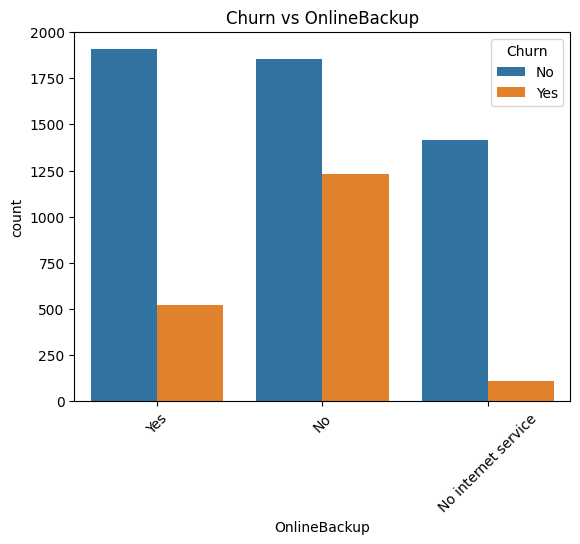

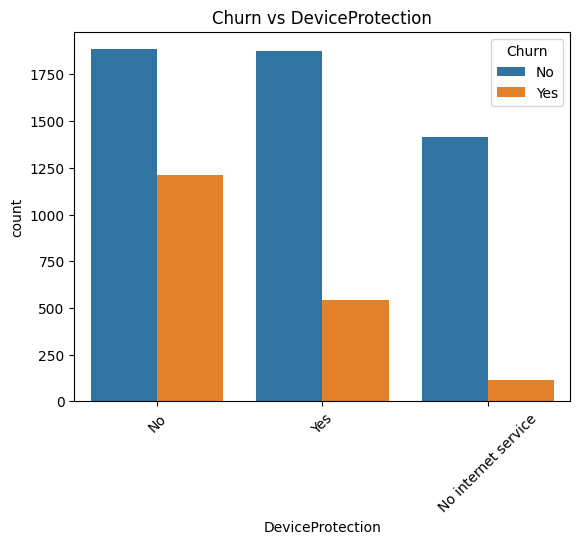

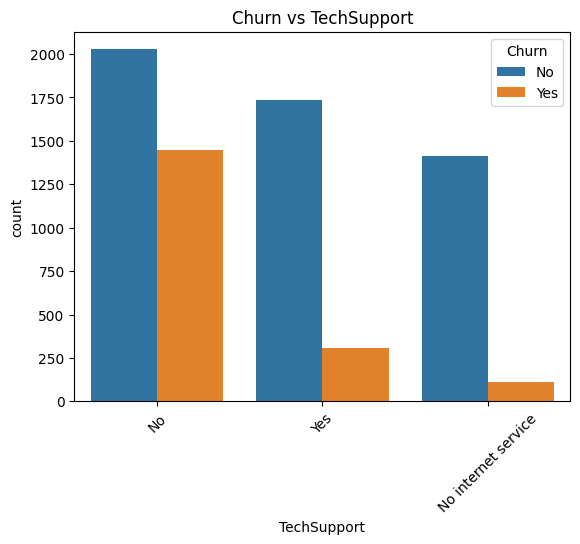

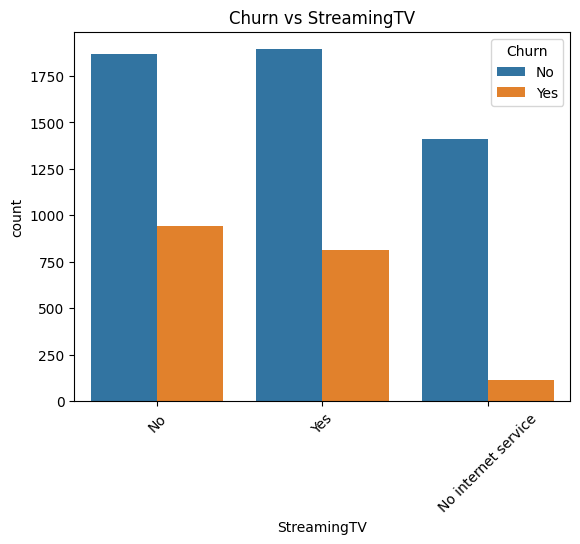

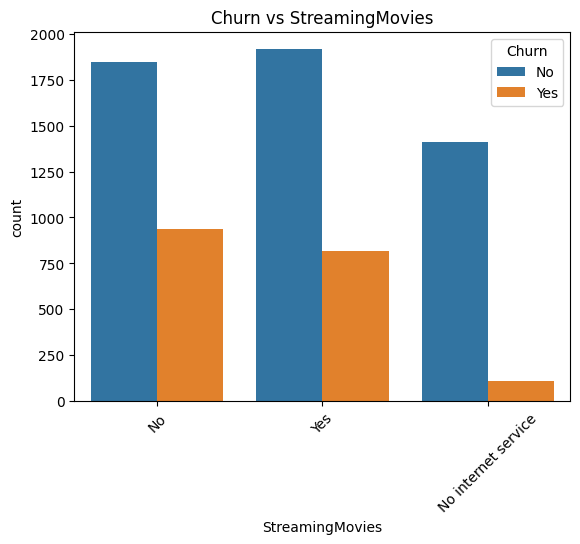

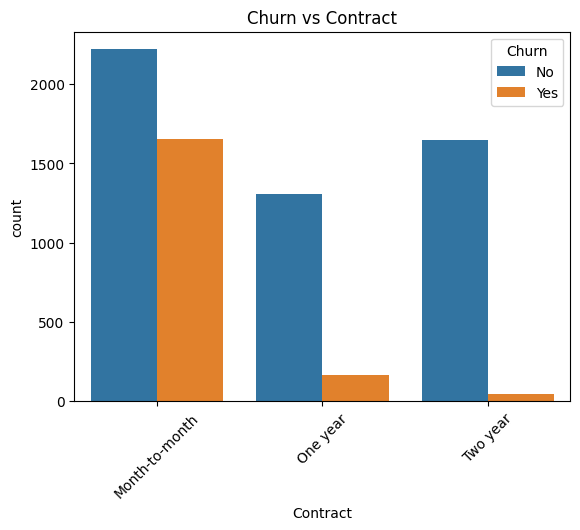

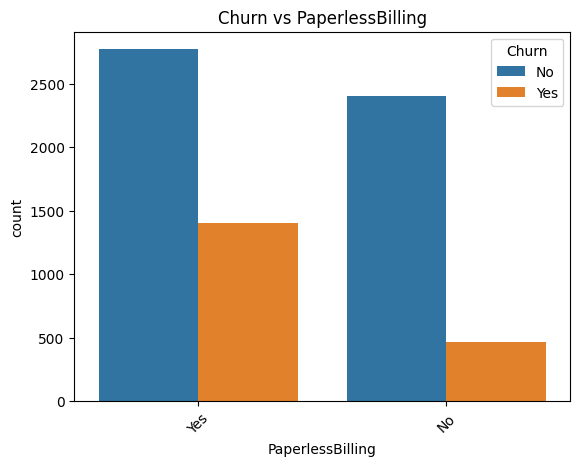

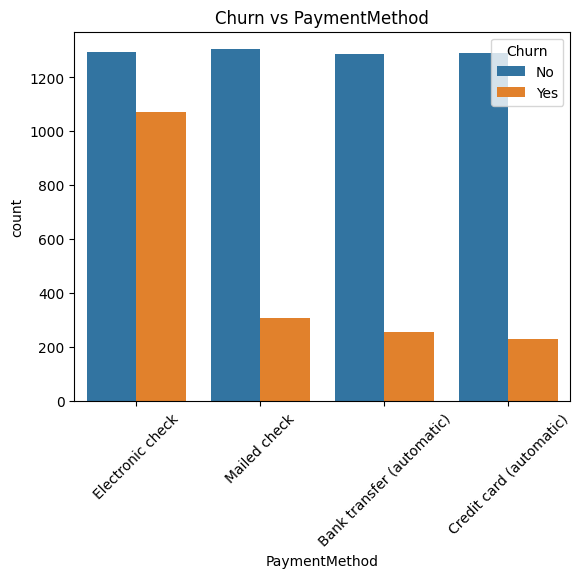

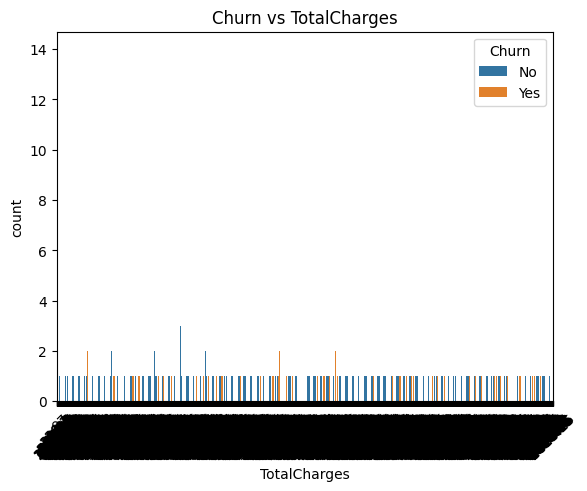

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col != 'Churn':
        plt.figure()
        sns.countplot(x=col, hue='Churn', data=df)
        plt.title(f'Churn vs {col}')
        plt.xticks(rotation=45)
        plt.show()

Insights:

*Contract Type: Month-to-month customers show higher churn

*Payment Method: Some payment types have more churn cases

*Internet Service: Certain services are linked with higher churn

*Tech Support & Online Security: Customers without these services churn more

*Gender: No significant difference in churn

● Churn vs numerical features

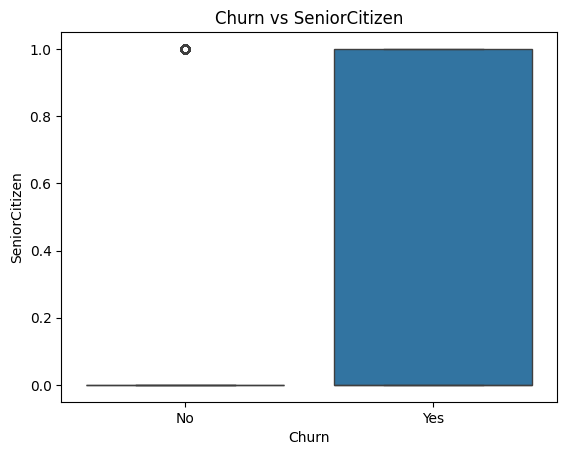

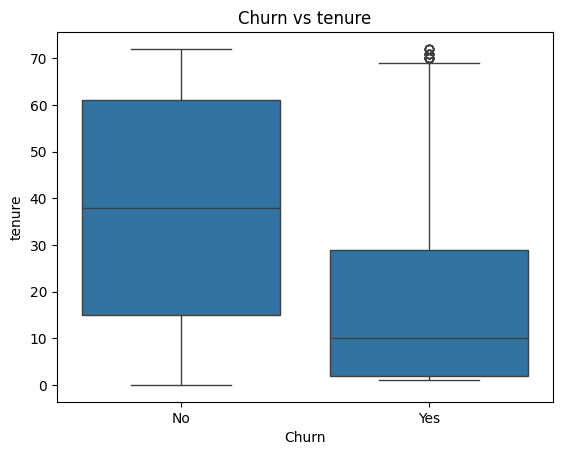

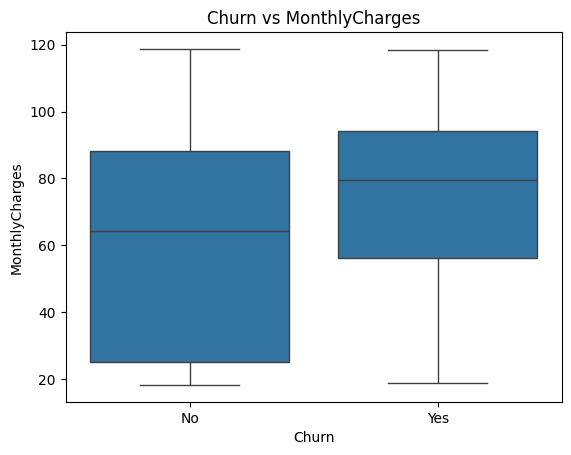

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'Churn vs {col}')
    plt.show()

Insights:

*Tenure: Customers with low tenure churn more

*Monthly Charges: Higher charges show more churn tendency

*Total Charges: Lower total charges → higher churn (new customers)

*Support Calls: More calls → higher churn risk

**8. Generate Correlation Heatmap**

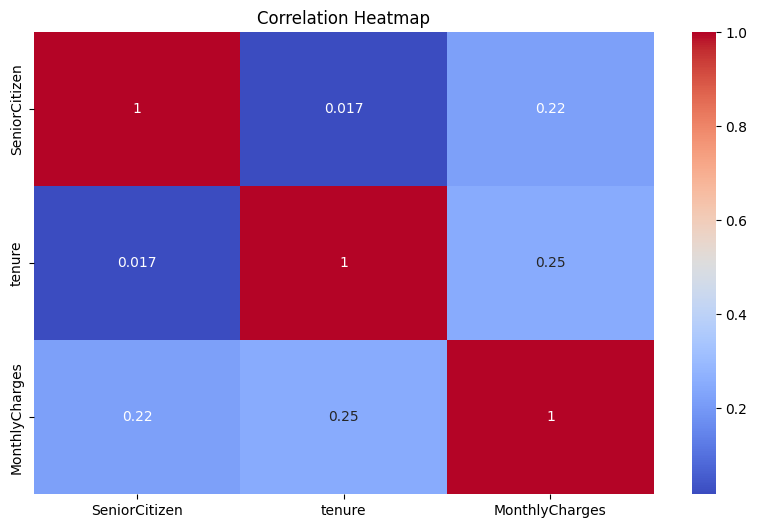

In [ ]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insights:

*Most features show low to moderate correlation, meaning they are not strongly related to each other

*Tenure & Total Charges have a strong positive correlation

→ Customers who stay longer spend more

*Monthly Charges & Total Charges show moderate correlation

→ Higher monthly cost leads to higher total spending over time

*No feature shows very high negative correlation

*Features are not highly correlated with each other

→ Good for machine learning (reduces multicollinearity problem)

**9. Detect and Handle Outliers**

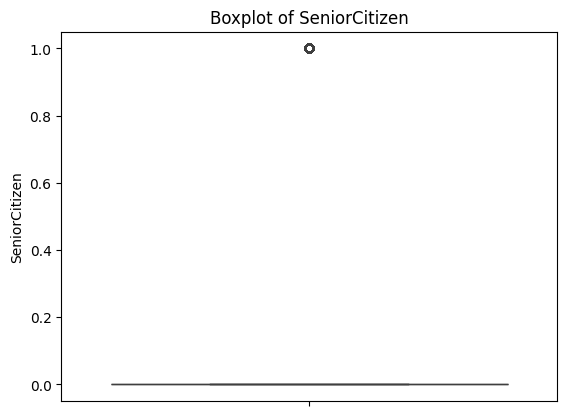

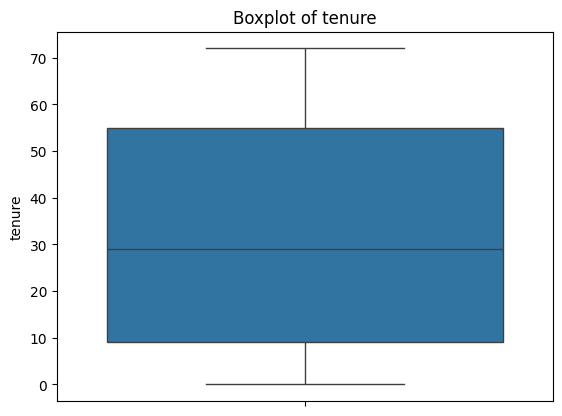

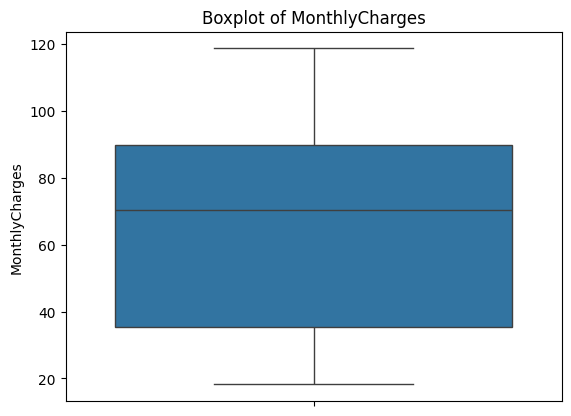

In [ ]:
# Detect outliers using boxplots
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()



In [ ]:
# Display IQR values and bounds for each numerical column
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print("-" * 40)

SeniorCitizen
Q1: 0.0, Q3: 0.0, IQR: 0.0
Lower Bound: 0.0, Upper Bound: 0.0
----------------------------------------
tenure
Q1: 9.0, Q3: 55.0, IQR: 46.0
Lower Bound: -60.0, Upper Bound: 124.0
----------------------------------------
MonthlyCharges
Q1: 35.5, Q3: 89.85, IQR: 54.349999999999994
Lower Bound: -46.02499999999999, Upper Bound: 171.375
----------------------------------------


**10. Apply Encoding**

● Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2504,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


● One-Hot Encoding

In [ ]:
# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2504,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


**11. Apply Scaling**

● StandardScaler / MinMaxScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.911890,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,...,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160299,-0.396626,-0.601023
1,0.216906,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,...,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259352,-0.946293,-0.601023
2,-0.470701,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,...,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362412,-1.639466,1.663829
3,0.990587,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,...,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746395,-0.981243,-0.601023
4,1.470632,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,...,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197770,-1.232776,1.663829


**12. Separate Features and Target Variable**

● X → Features

● y → Churn

In [ ]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

X.head(), y.head()

(   customerID    gender  SeniorCitizen   Partner  Dependents    tenure  \
 0    0.911890 -1.009559      -0.439916  1.034530   -0.654012 -1.277445   
 1    0.216906  0.990532      -0.439916 -0.966622   -0.654012  0.066327   
 2   -0.470701  0.990532      -0.439916 -0.966622   -0.654012 -1.236724   
 3    0.990587  0.990532      -0.439916 -0.966622   -0.654012  0.514251   
 4    1.470632 -1.009559      -0.439916 -0.966622   -0.654012 -1.236724   
 
    PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
 0     -3.054010       0.062723        -1.183234       -0.918838      1.242550   
 1      0.327438      -0.991588        -1.183234        1.407321     -1.029919   
 2      0.327438      -0.991588        -1.183234        1.407321      1.242550   
 3     -3.054010       0.062723        -1.183234        1.407321     -1.029919   
 4      0.327438      -0.991588         0.172250       -0.918838     -1.029919   
 
    DeviceProtection  TechSupport  StreamingTV  Stream

**13. Perform Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5634, 20), (1409, 20))

**14. Handle Imbalanced Data**

● Apply SMOTE

In [ ]:
X_train.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Fill all missing values with median
X_train = X_train.fillna(X_train.median())

In [ ]:
y_train = y_train.astype(int)

In [ ]:
y_train = y_train.round().astype(int)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

**15. Train Classification Models**

● Logistic Regression

In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# FIX: ensure target is categorical
y_train_smote = y_train_smote.astype(int)
y_test = y_test.astype(int)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7565649396735273


● K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_smote, y_train_smote)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6855926188786373


● Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.723207948899929


● Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7877927608232789


● Support Vector Classifier (SVC)

In [ ]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train_smote, y_train_smote)

y_pred_svc = svc.predict(X_test)
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

SVC Accuracy: 0.7700496806245565


● Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.801277501774308


● XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:44:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7814052519517388


**16. Evaluate Models Using**

● Accuracy

● Precision

● Recall

● F1 Score

● ROC-AUC Score

● Confusion Matrix

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(model, X_test, y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Evaluation")

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 Score:", f1)

    # ROC-AUC
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
        print("ROC-AUC:", roc)
    except:
        print("ROC-AUC: Not available for this model")

    # Confusion Matrix
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# 🔹 Call for each model

evaluate_model(lr, X_test, y_test, y_pred_lr, "Logistic Regression")
evaluate_model(knn, X_test, y_test, y_pred_knn, "KNN")
evaluate_model(dt, X_test, y_test, y_pred_dt, "Decision Tree")
evaluate_model(rf, X_test, y_test, y_pred_rf, "Random Forest")
evaluate_model(svc, X_test, y_test, y_pred_svc, "SVC")
evaluate_model(gb, X_test, y_test, y_pred_gb, "Gradient Boosting")
evaluate_model(xgb, X_test, y_test, y_pred_xgb, "XGBoost")

**17. Apply Hyperparameter Tuning**

● GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

grid = GridSearchCV(RandomForestClassifier(), {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}, cv=3)

grid.fit(X_train_smote, y_train_smote)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


● RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rand = RandomizedSearchCV(RandomForestClassifier(), {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None]
}, n_iter=5, cv=3, random_state=42)

rand.fit(X_train_smote, y_train_smote)

print(rand.best_params_)

{'n_estimators': 300, 'max_depth': None}


**18. Compare Model Performance**

● Create comparison table

In [ ]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVC', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.756565
1                  KNN  0.685593
2        Decision Tree  0.723208
3        Random Forest  0.787793
4                  SVC  0.770050
5    Gradient Boosting  0.801278
6              XGBoost  0.781405


● Identify best model

In [ ]:
# Identify best model
best_model = results.loc[results['Accuracy'].idxmax()]
print("\nBest Model:\n", best_model)


Best Model:
 Model       Gradient Boosting
Accuracy             0.801278
Name: 5, dtype: object


**19. Select Best Model**

 ● Based on metrics

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVC', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svc),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svc),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svc),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.756565   0.526316  0.804290  0.636267
1                  KNN  0.685593   0.443182  0.731903  0.552073
2        Decision Tree  0.723208   0.480278  0.554960  0.514925
3        Random Forest  0.787793   0.597884  0.605898  0.601864
4                  SVC  0.770050   0.549696  0.726542  0.625866
5    Gradient Boosting  0.801278   0.599572  0.750670  0.666667
6              XGBoost  0.781405   0.585752  0.595174  0.590426


In [ ]:
# Select best model based on F1 Score (balanced metric)
best_model = results.loc[results['F1 Score'].idxmax()]
print("\nBest Model Based on F1 Score:\n", best_model)


Best Model Based on F1 Score:
 Model        Gradient Boosting
Accuracy              0.801278
Precision             0.599572
Recall                 0.75067
F1 Score              0.666667
Name: 5, dtype: object


● Business interpretation

*The model helps the company identify customers who are likely to leave before they actually churn

*By focusing on recall, we make sure that we don’t miss customers who might leave, which is very important for the business

*At the same time, precision ensures that the customers we target are actually at risk, so the company doesn’t waste time or resources

*Since the selected model has a good balance between precision and recall (F1 score), it gives reliable predictions

*This can help the company:

       

*   Reach out to customers before they leave



  
*   Provide better offers or support

*   Improve overall customer satisfaction






**20. Final Insights**

Key Factors Influencing Churn

*Customers with high monthly charges are more likely to leave, possibly because they feel the service is expensive

*Customers on month-to-month contracts tend to churn more since they are not committed long-term

*Customers who do not have tech support are more likely to leave due to lack of assistance when facing issues

*Customers with short tenure (new customers) have a higher chance of leaving compared to long-term customers

Business Recommendations

*The company can encourage customers to stay longer by offering attractive discounts on long-term plans, so they feel it’s more valuable to continue

*Improving customer support is very important. When customers get quick and helpful solutions, they are less likely to leave

*Giving personalized offers and plans based on customer needs can make them feel more important and understood

*By using the model, the company can identify customers who are likely to leave early and take action before they actually churn

*Introducing loyalty programs, rewards, or benefits can build a stronger relationship with customers and keep them engaged

**Conclusion**

In this project, we focused on understanding why customers leave and how we can predict it using machine learning. We started by analyzing the data, cleaning it, and exploring different patterns to identify the key factors affecting customer churn.

We then built multiple machine learning models and compared their performance using different evaluation metrics. Based on these results, we selected the best model that provides reliable and balanced predictions.

From our analysis, we found that factors like high monthly charges, short tenure, lack of support services, and flexible contracts play a major role in customer churn. Using these insights, we also suggested business strategies to help reduce churn and improve customer retention.

Overall, this project shows how data and machine learning can help businesses make better decisions, take early actions, and improve customer satisfaction.